In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("ddos_dataset.csv", low_memory=False)
df.columns = df.columns.str.strip()




In [3]:
df['label'].unique()


array(['ddos_dns', 'benign', 'ddos_ldap', 'ddos_mssql', 'ddos_netbios',
       'ddos_ntp', nan], dtype=object)

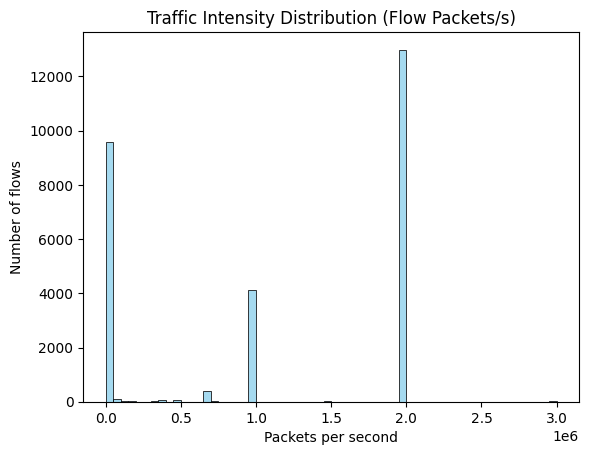

In [4]:
#Histogram for Flow packets/s

packets = pd.to_numeric(df["Flow Packets/s"], errors="coerce").dropna()

sns.histplot(packets, bins=60, color="skyblue")
plt.title("Traffic Intensity Distribution (Flow Packets/s)")
plt.xlabel("Packets per second")
plt.ylabel("Number of flows")
plt.show()



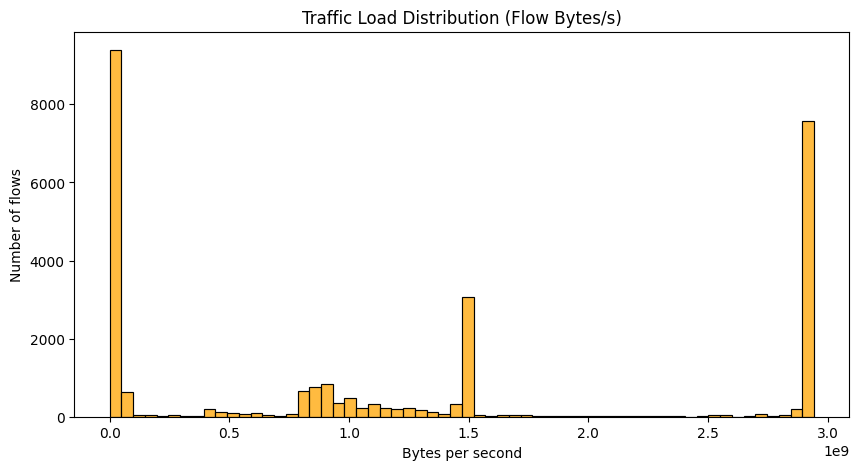

In [5]:
#Histogram for Flow Bytes/s

bytes_sec = pd.to_numeric(df["Flow Bytes/s"], errors="coerce").dropna()

plt.figure(figsize=(10,5))
sns.histplot(bytes_sec, bins=60, color="orange")
plt.title("Traffic Load Distribution (Flow Bytes/s)")
plt.xlabel("Bytes per second")
plt.ylabel("Number of flows")
plt.show()


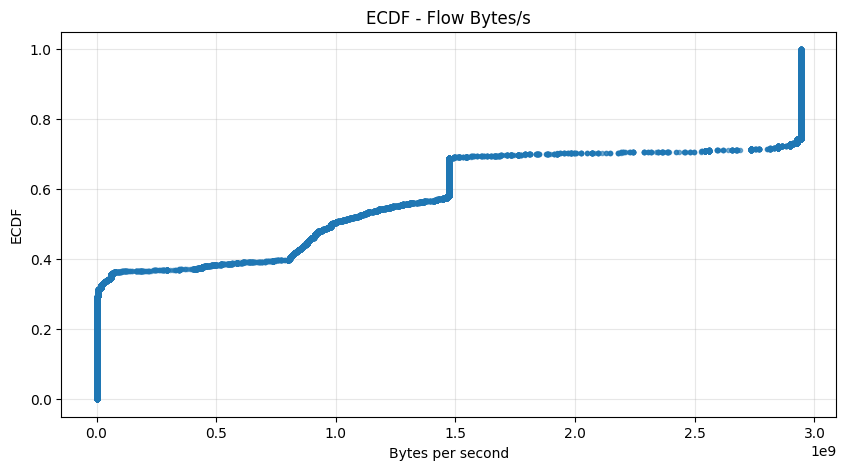

In [6]:
#Empirical cumulative distribution function


bytes_sorted = np.sort(bytes_sec)
ecdf = np.arange(1, len(bytes_sorted)+1) / len(bytes_sorted)

plt.figure(figsize=(10,5))
plt.plot(bytes_sorted, ecdf, marker=".", linestyle="none", alpha=0.6)
plt.title("ECDF - Flow Bytes/s")
plt.xlabel("Bytes per second")
plt.ylabel("ECDF")
plt.grid(alpha=0.3)
plt.show()


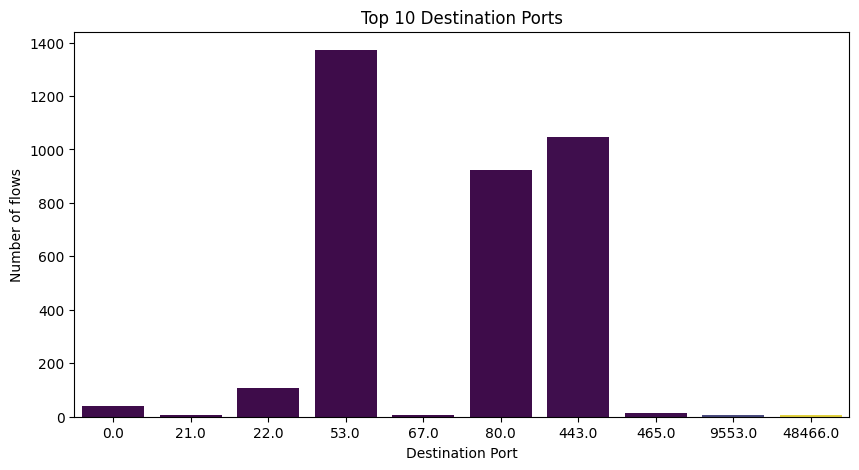

In [7]:
dest_ports = pd.to_numeric(df["Destination Port"], errors="coerce").dropna()
top_ports = dest_ports.value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_ports.index, y=top_ports.values, hue=top_ports.index, palette="viridis", legend=False)
plt.title("Top 10 Destination Ports")
plt.xlabel("Destination Port")
plt.ylabel("Number of flows")
plt.show()


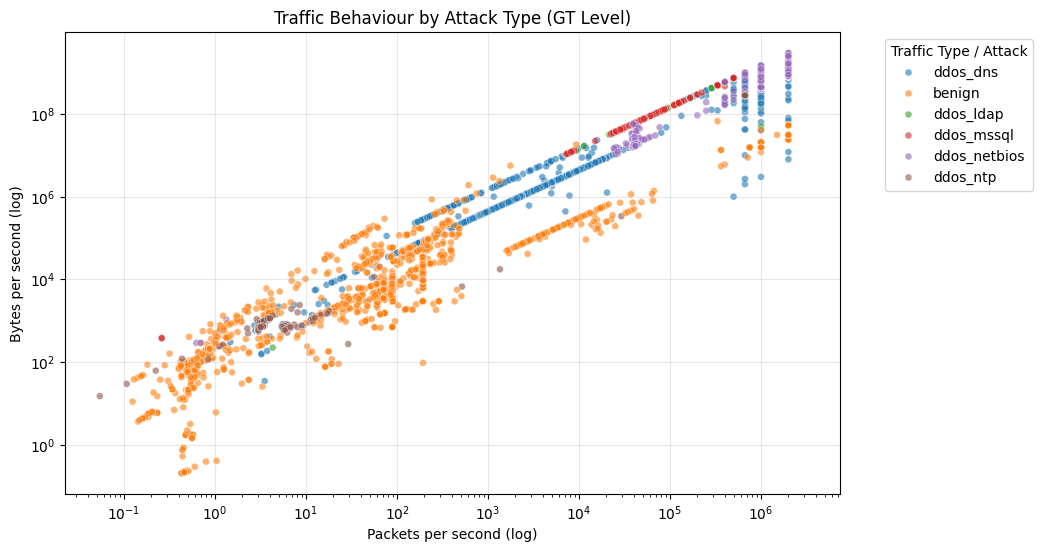

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Flow Packets/s',
    y='Flow Bytes/s',
    hue='label',
    palette='tab10',
    alpha=0.6,
    s=25
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Packets per second (log)")
plt.ylabel("Bytes per second (log)")
plt.title("Traffic Behaviour by Attack Type (GT Level)")
plt.legend(title="Traffic Type / Attack", bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
#We check columns with Nan values

(df.isna().mean() * 100).sort_values(ascending=False)



,0
Source Port,0.003644
Source IP,0.003644
Destination Port,0.003644
Destination IP,0.003644
Protocol,0.003644
...,...
Idle Max,0.003644
Inbound,0.003644
label,0.003644
Unnamed: 0,0.000000


In [10]:
def save():
    df.to_csv("ddos_clean.csv", index=False)
    print("Saved file")

save()


Saved file


In [11]:
import re

column_status = {}

for col in df.columns:
    column_status[col] = df[col].astype(str).apply(
        lambda x: bool(re.search(r"[^0-9\.\-\+eE]", x))
    ).any()

for col, status in column_status.items():
    print(f"{col}: {'Contain symbols' if status else 'valid value'}")



Unnamed: 0: valid value
Flow ID: valid value
Source IP: Contain symbols
Source Port: Contain symbols
Destination IP: Contain symbols
Destination Port: Contain symbols
Protocol: Contain symbols
Timestamp: Contain symbols
Flow Duration: Contain symbols
Total Fwd Packets: Contain symbols
Total Backward Packets: Contain symbols
Total Length of Fwd Packets: Contain symbols
Total Length of Bwd Packets: Contain symbols
Fwd Packet Length Max: Contain symbols
Fwd Packet Length Min: Contain symbols
Fwd Packet Length Mean: Contain symbols
Fwd Packet Length Std: Contain symbols
Bwd Packet Length Max: Contain symbols
Bwd Packet Length Min: Contain symbols
Bwd Packet Length Mean: Contain symbols
Bwd Packet Length Std: Contain symbols
Flow Bytes/s: Contain symbols
Flow Packets/s: Contain symbols
Flow IAT Mean: Contain symbols
Flow IAT Std: Contain symbols
Flow IAT Max: Contain symbols
Flow IAT Min: Contain symbols
Fwd IAT Total: Contain symbols
Fwd IAT Mean: Contain symbols
Fwd IAT Std: Contain symbo

In [12]:
df.dtypes[df.dtypes == "object"]



,0
Flow ID,object
Source IP,object
Destination IP,object
Timestamp,object
SimillarHTTP,object
label,object


In [13]:
non_numeric = ["Flow ID", "Source IP", "Destination IP", "Timestamp", "SimillarHTTP", "label"]
df_num = df.drop(columns=non_numeric)


In [14]:
df_num.dtypes.value_counts()


,count
float64,81
int64,1


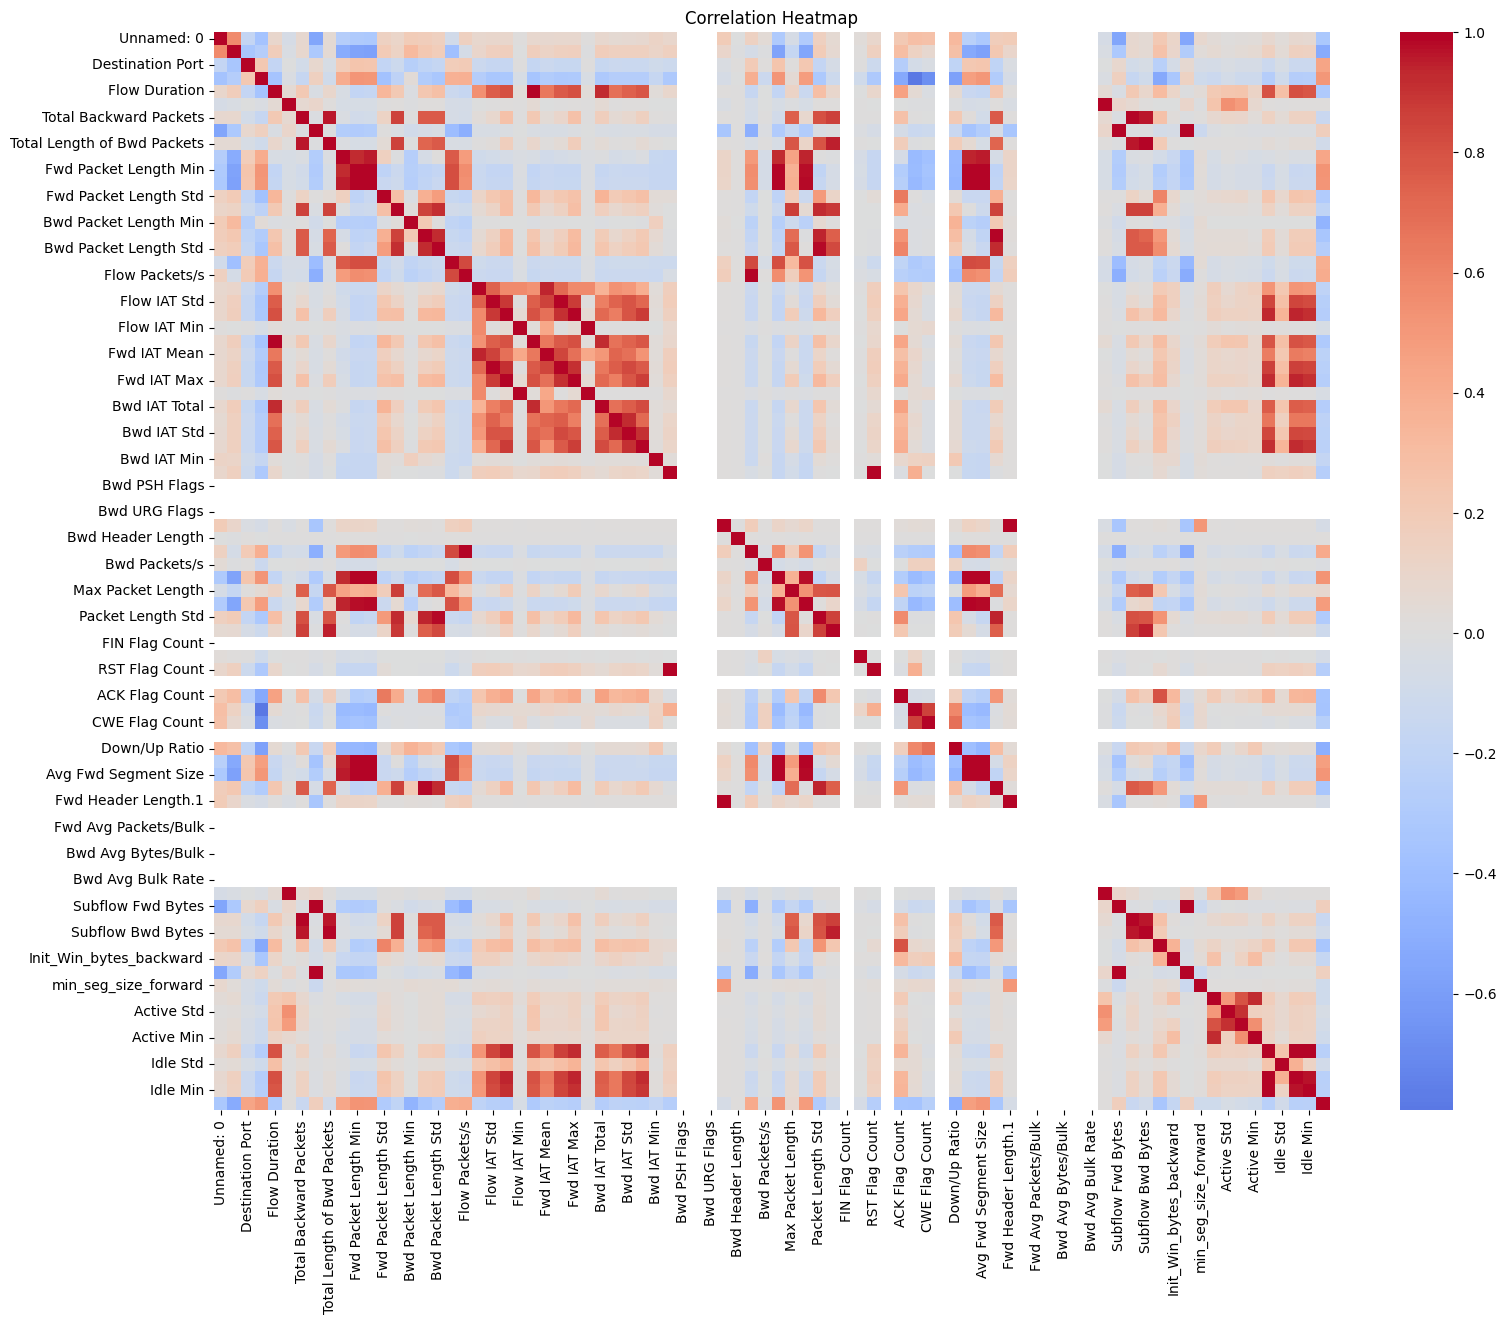

In [15]:
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,14))
sns.heatmap(df_num.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

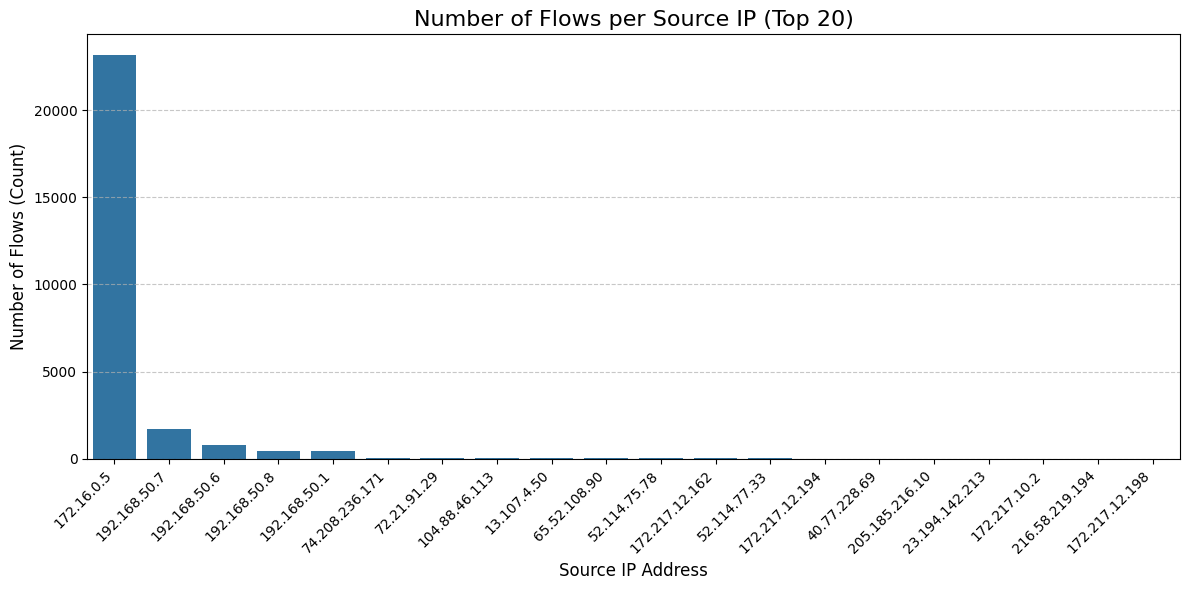

In [16]:
# 1. Aggregate the data (Counting flows per Source IP)
flow_counts = df['Source IP'].value_counts().sort_values(ascending=False)

# 2. Plot the top 20 IPs for readability
top_n = 20
plot_data = flow_counts.head(top_n)

# 3. Create the Bar Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=plot_data.index, y=plot_data.values)
plt.title(f'Number of Flows per Source IP (Top {top_n})', fontsize=16)
plt.xlabel('Source IP Address', fontsize=12)
plt.ylabel('Number of Flows (Count)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()



In [17]:
print(df['Source IP'].value_counts(normalize=True).sort_values(ascending=False))
print(df['Destination IP'].value_counts(normalize=True).sort_values(ascending=False))


Source IP
172.16.0.5        0.844777
192.168.50.7      0.063088
192.168.50.6      0.028646
192.168.50.8      0.017458
192.168.50.1      0.017421
                    ...   
18.213.117.114    0.000036
172.217.9.227     0.000036
52.114.74.45      0.000036
35.160.216.194    0.000036
40.124.45.19      0.000036
Name: proportion, Length: 175, dtype: float64
Destination IP
192.168.50.1     0.844814
4.2.2.4          0.039252
172.16.0.5       0.016656
192.168.50.7     0.016073
8.8.8.8          0.010752
                   ...   
91.189.94.4      0.000036
172.217.10.74    0.000036
91.189.89.199    0.000036
54.192.49.232    0.000036
104.88.90.6      0.000036
Name: proportion, Length: 199, dtype: float64


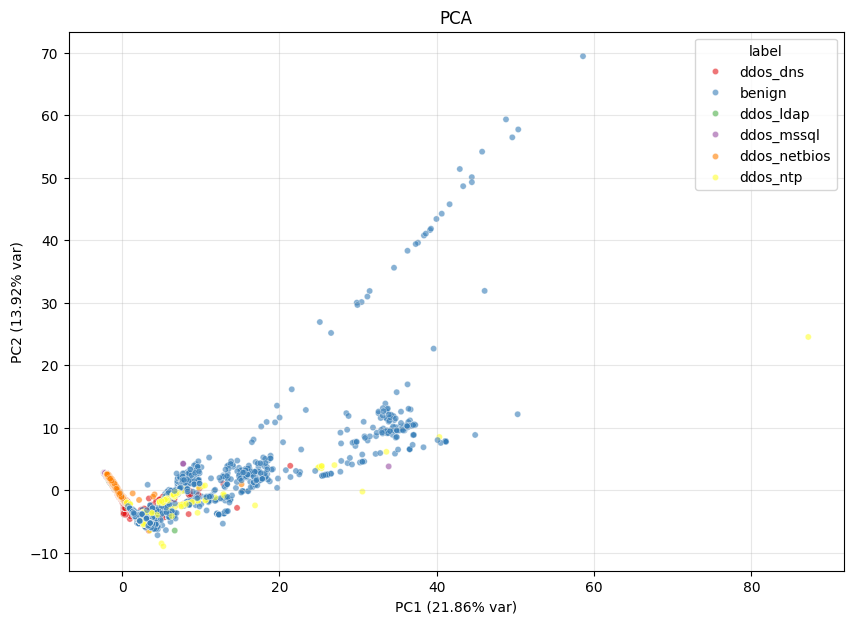

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np # Ensure numpy is imported for np.inf, np.nan

# Select only numeric columns
df_numeric_for_pca = df.select_dtypes(include=['int64','float64']).copy()

# Replace infinite values with NaN and then drop rows containing NaNs
# This ensures a clean dataset for PCA without losing too many features
df_numeric_for_pca = df_numeric_for_pca.replace([np.inf, -np.inf], np.nan).dropna()

# Check if there are enough features after cleaning
if df_numeric_for_pca.shape[1] < 2:
    print("Not enough numeric features remaining after cleaning for PCA with 2 components.")
else:
    scaler = StandardScaler()
    df_scaled = scaler.fit_transform(df_numeric_for_pca)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(df_scaled)

    plt.figure(figsize=(10,7))
    sns.scatterplot(
        x=X_pca[:,0], y=X_pca[:,1],
        hue=df.loc[df_numeric_for_pca.index, 'label'], # Ensure labels correspond to the filtered data
        palette='Set1', alpha=0.6, s=20
    )
    plt.title("PCA")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
    plt.grid(alpha=0.3)
    plt.show()

In [20]:

print("Amount of samples by type of traffic:")
display(df['label'].value_counts())

print("Porcentage of samples by class:")
display((df['label'].value_counts(normalize=True)*100).round(2))


Amount of samples by type of traffic:


,count
label,
ddos_ldap,5928
ddos_mssql,5911
ddos_netbios,5830
ddos_dns,5369
benign,3802
ddos_ntp,598


Porcentage of samples by class:


,proportion
label,
ddos_ldap,21.61
ddos_mssql,21.54
ddos_netbios,21.25
ddos_dns,19.57
benign,13.86
ddos_ntp,2.18


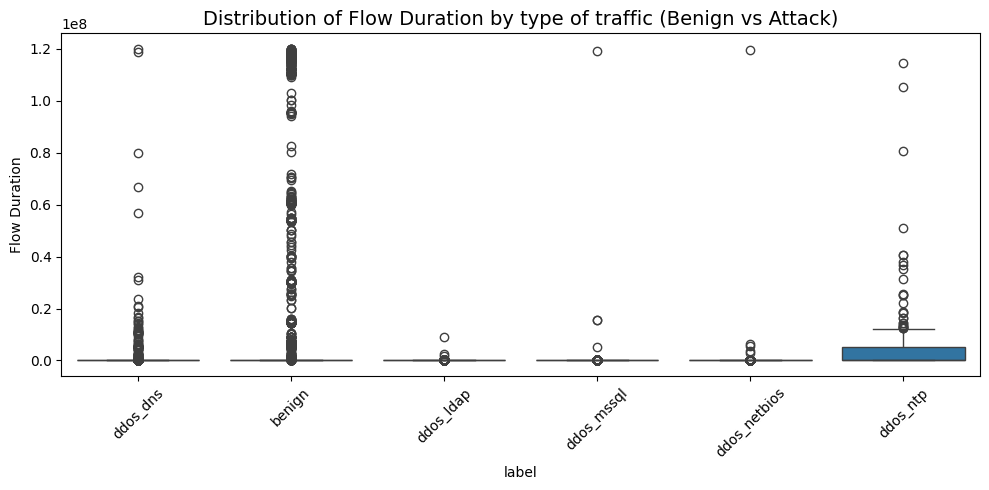

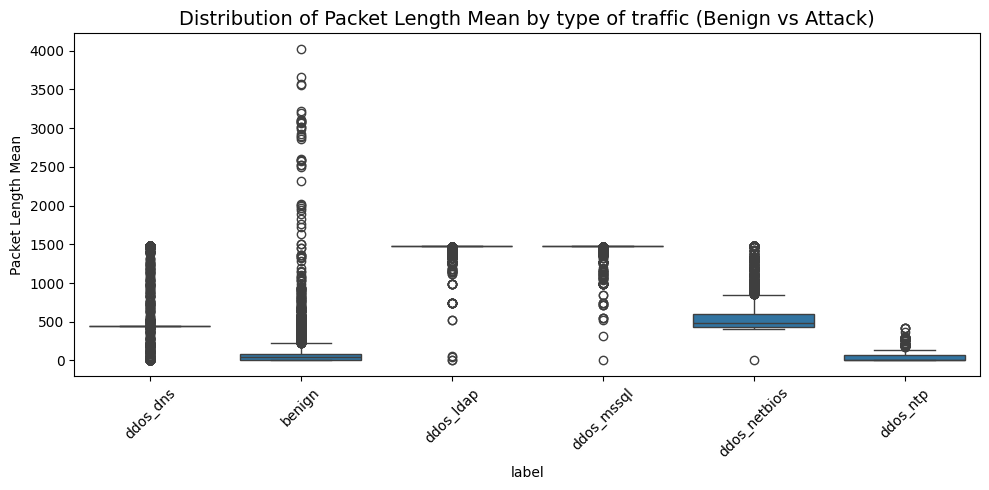

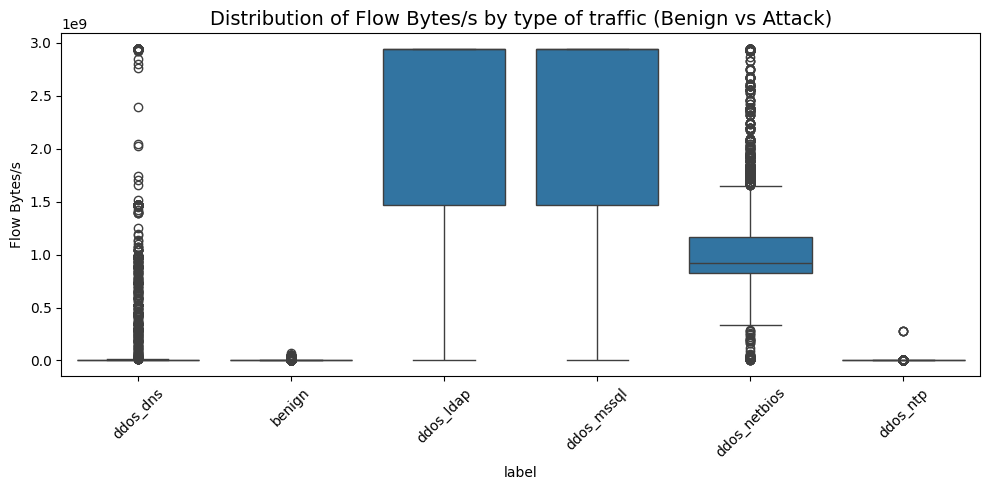

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

features_box = ['Flow Duration', 'Packet Length Mean', 'Flow Bytes/s']

for col in features_box:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x='label', y=col)
    plt.title(f"Distribution of {col} by type of traffic (Benign vs Attack)", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

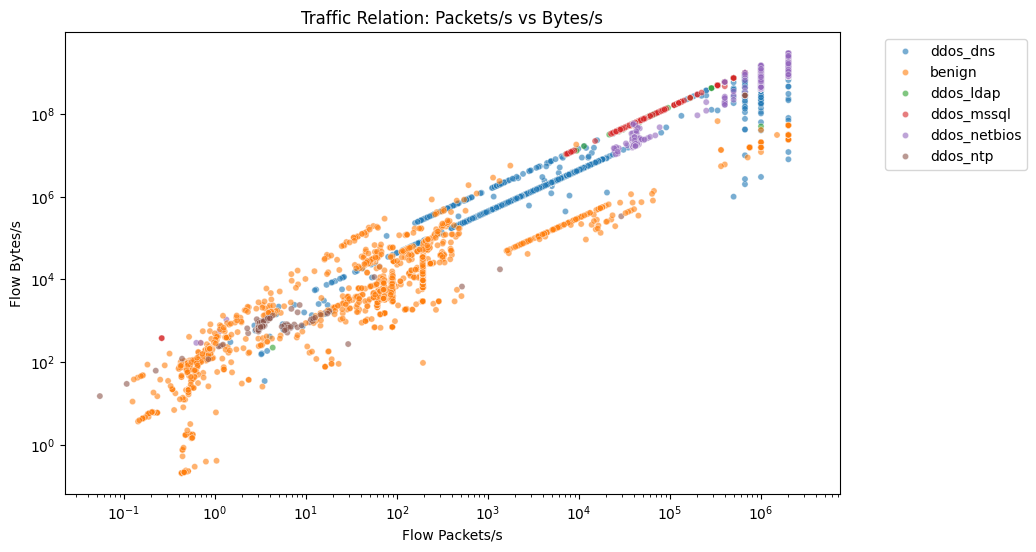

In [22]:

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Flow Packets/s', y='Flow Bytes/s', hue='label', alpha=0.6, s=20)
plt.xscale('log'); plt.yscale('log')
plt.title("Traffic Relation: Packets/s vs Bytes/s")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()


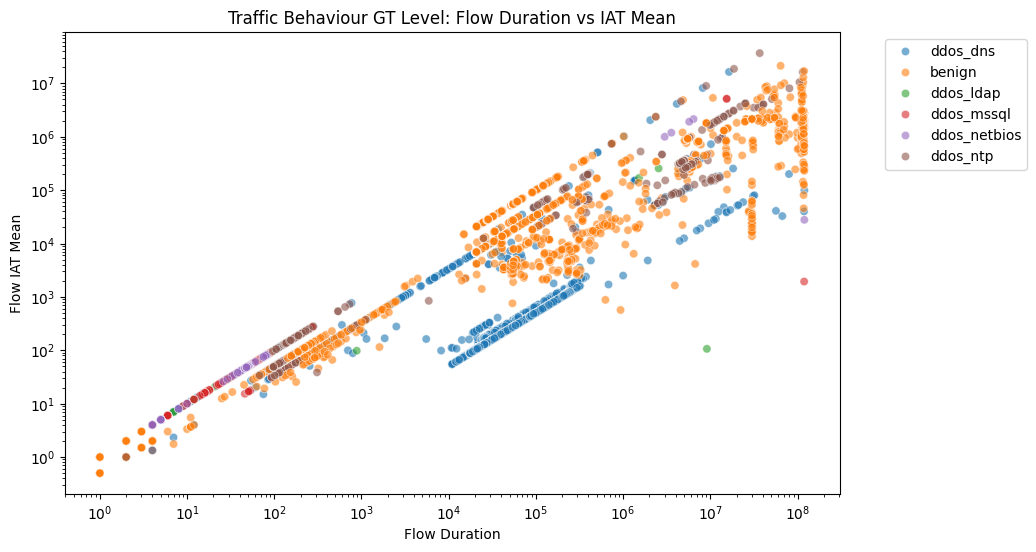

In [23]:
if 'Flow IAT Mean' in df.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=df, x='Flow Duration', y='Flow IAT Mean', hue='label', alpha=0.6)
    plt.xscale('log'); plt.yscale('log')
    plt.title("Traffic Behaviour GT Level: Flow Duration vs IAT Mean")
    plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
    plt.show()


In [24]:
import numpy as np
import pandas as pd

df.columns = df.columns.str.strip()



df['total_packets'] = df['Total Fwd Packets'] + df['Total Backward Packets']

df['total_bytes'] = df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets']



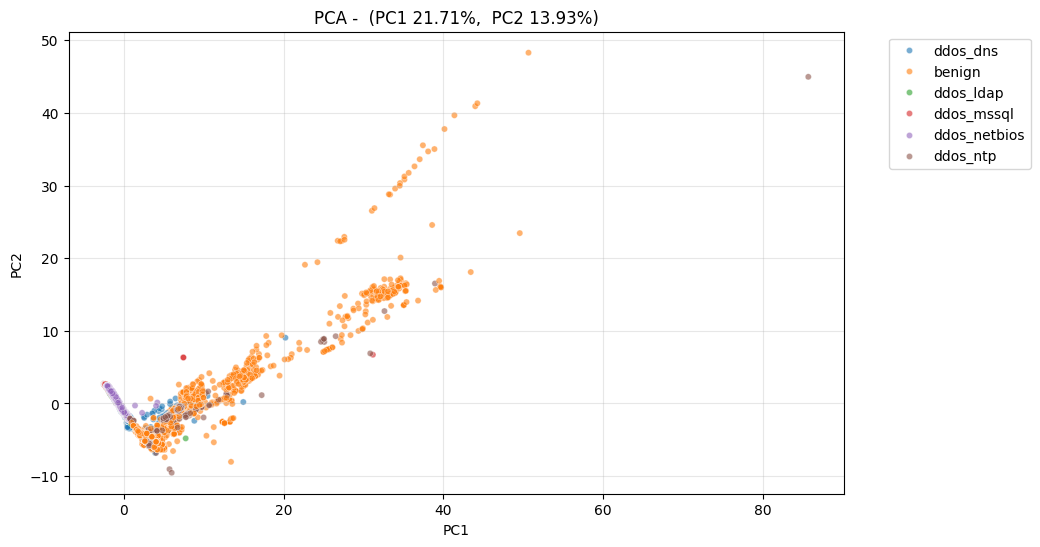

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


df_num2 = df.select_dtypes(include=['int64','float64']).copy()

df_num2['label'] = df['label']


cols_drop = ['Flow Duration','Total Fwd Packets','Total Backward Packets',
             'Total Length of Fwd Packets','Total Length of Bwd Packets']

df_pca = df_num2.drop(columns=[c for c in cols_drop if c in df_num2.columns] + ['label'], errors='ignore')


df_pca = df_pca.replace([np.inf,-np.inf], np.nan).dropna()


scaler = StandardScaler()
X_scaled2 = scaler.fit_transform(df_pca)


pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled2)


plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca2[:,0], y=X_pca2[:,1],
    hue=df_num2.loc[df_pca.index, 'label'],
    s=20, alpha=0.6, palette="tab10"
)

plt.title(f"PCA -  (PC1 {pca2.explained_variance_ratio_[0]*100:.2f}%,  PC2 {pca2.explained_variance_ratio_[1]*100:.2f}%)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(alpha=0.3)
plt.show()



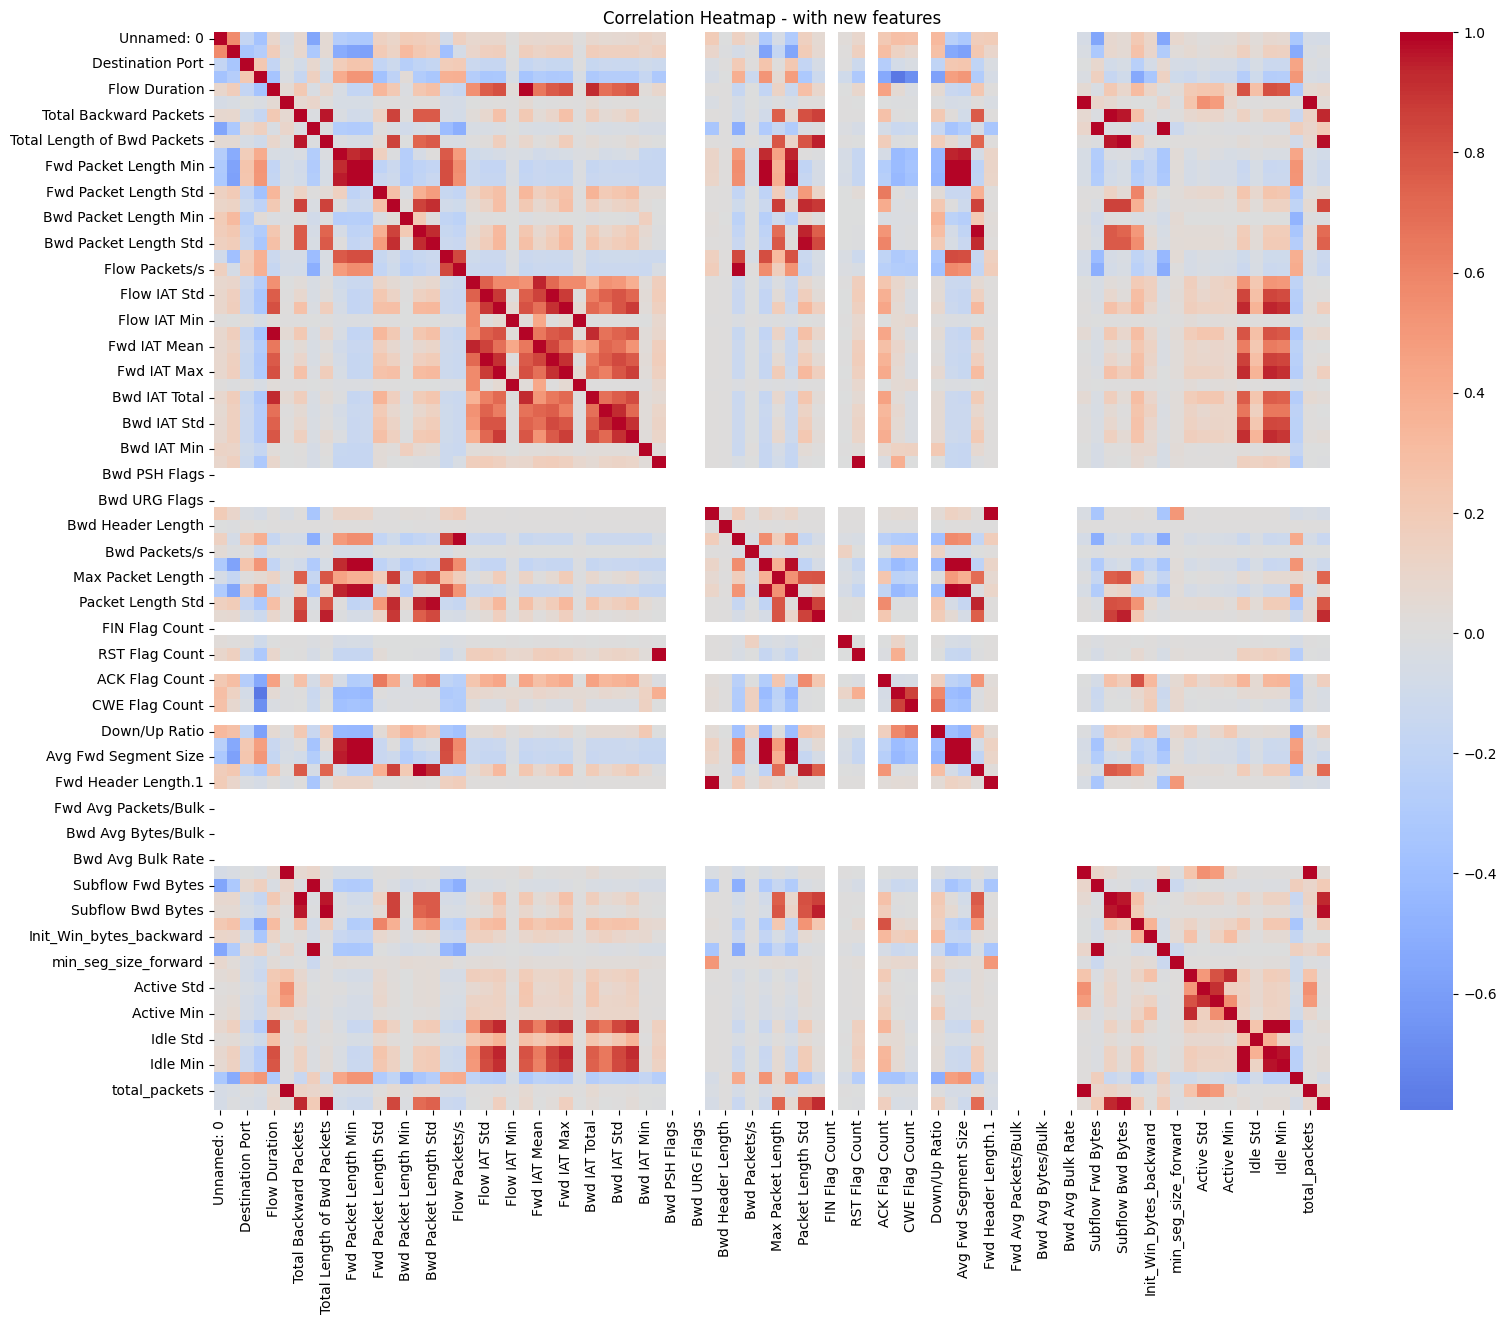

In [27]:

df_corr = df_num2.drop(columns=['label'], errors='ignore')

plt.figure(figsize=(18,14))
sns.heatmap(df_corr.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - with new features")
plt.show()


/tmp/ipython-input-3460366611.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


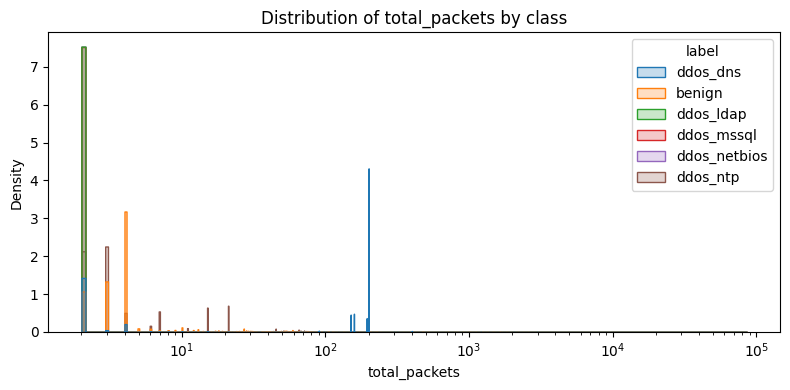

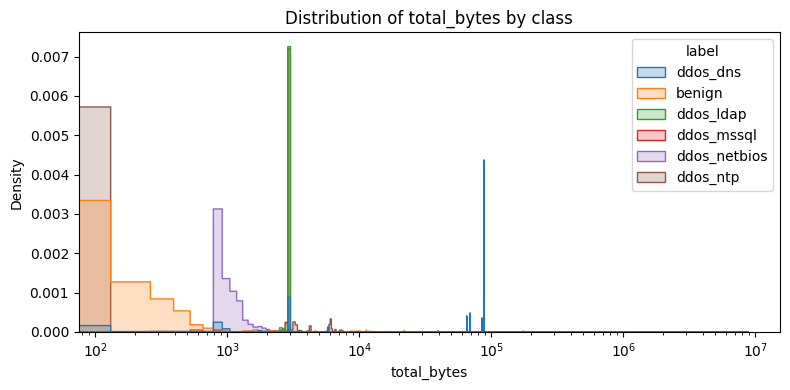

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

features_new = ['total_packets','total_bytes']

for col in features_new:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=col, hue='label', element='step', stat='density', common_norm=False)
    plt.title(f"Distribution of {col} by class")
    plt.xscale('log')
    plt.tight_layout()
    plt.show()


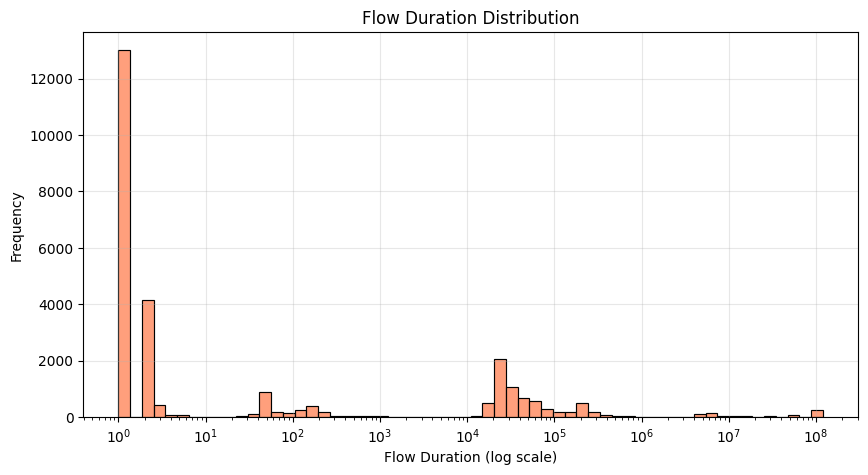

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(df['Flow Duration'], bins=60, color="coral", log_scale=True)
plt.title("Flow Duration Distribution")
plt.xlabel("Flow Duration (log scale)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


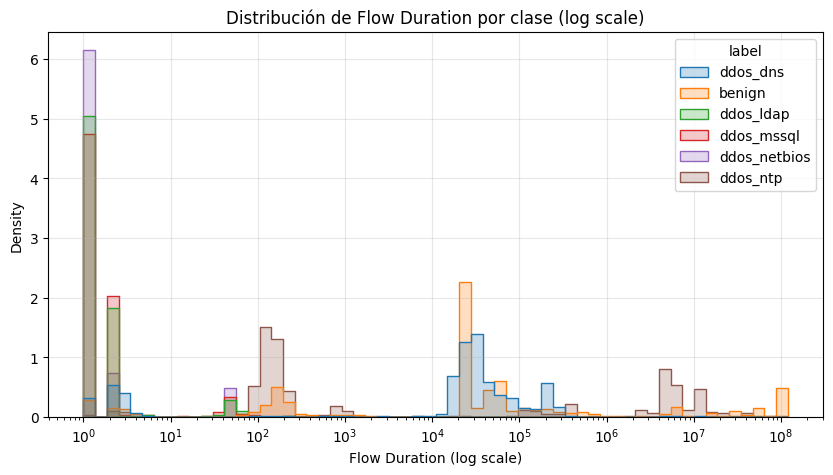

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Flow Duration', hue='label', bins=60, element='step', stat='density', common_norm=False, log_scale=True)
plt.title("Distribución de Flow Duration por clase (log scale)")
plt.xlabel("Flow Duration (log scale)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


In [34]:

columns_to_drop = [
    'Flow ID',
    'SimillarHTTP',
]


unnamed = [col for col in df.columns if col.lower().startswith("unnamed")]


df.drop(columns=columns_to_drop + unnamed, axis=1, inplace=True, errors='ignore')

print("Deleted columns:")
for col in columns_to_drop + unnamed:
    print(f" - {col}")


Deleted columns:
 - Flow ID
 - SimillarHTTP
 - Unnamed: 0


In [35]:
df.to_csv("dataset_clean_step1.csv", index=False)
print("File saved as dataset_clean_step1.csv")


File saved as dataset_clean_step1.csv


In [36]:

df_num = df.select_dtypes(include=['int64','float64'])

import numpy as np

corr_matrix = df_num.corr().abs()


high_corr_pairs = [
    (col1, col2, corr_matrix.loc[col1, col2])
    for i, col1 in enumerate(corr_matrix.columns)
    for j, col2 in enumerate(corr_matrix.columns)
    if i < j and corr_matrix.loc[col1, col2] > 0.90
]

print("Pais with correlation > 0.90:\n")
for p in high_corr_pairs:
    print(f"{p[0]:30}  <-->  {p[1]:30}  |  corr = {p[2]:.3f}")




Pais with correlation > 0.90:

Flow Duration                   <-->  Fwd IAT Total                   |  corr = 0.998
Flow Duration                   <-->  Bwd IAT Total                   |  corr = 0.929
Total Fwd Packets               <-->  Subflow Fwd Packets             |  corr = 1.000
Total Fwd Packets               <-->  total_packets                   |  corr = 0.998
Total Backward Packets          <-->  Total Length of Bwd Packets     |  corr = 0.958
Total Backward Packets          <-->  Subflow Bwd Packets             |  corr = 1.000
Total Backward Packets          <-->  Subflow Bwd Bytes               |  corr = 0.958
Total Backward Packets          <-->  total_bytes                     |  corr = 0.935
Total Length of Fwd Packets     <-->  Subflow Fwd Bytes               |  corr = 1.000
Total Length of Fwd Packets     <-->  act_data_pkt_fwd                |  corr = 0.998
Total Length of Bwd Packets     <-->  Packet Length Variance          |  corr = 0.945
Total Length of Bwd Pac

In [37]:
import numpy as np

corr_matrix = df_num.corr().abs()


upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


to_drop_auto = [column for column in upper.columns if any(upper[column] > 0.90)]

print("Columns to delete because of correlation > 0.90:\n")
for col in to_drop_auto:
    print(" -", col)

77333333
df_final = df_num.drop(columns=to_drop_auto, errors='ignore')

print(f"\nFinal features after reduction: {df_final.shape[1]} columns")

df_final.to_csv("dataset_clean_final.csv", index=False)
print("Saved as dataset_clean_final.csv")


Columns to delete because of correlation > 0.90:

 - Total Length of Bwd Packets
 - Fwd Packet Length Min
 - Fwd Packet Length Mean
 - Bwd Packet Length Std
 - Fwd IAT Total
 - Fwd IAT Mean
 - Fwd IAT Std
 - Fwd IAT Max
 - Fwd IAT Min
 - Bwd IAT Total
 - Bwd IAT Std
 - Bwd IAT Max
 - Fwd Packets/s
 - Min Packet Length
 - Packet Length Mean
 - Packet Length Std
 - Packet Length Variance
 - RST Flag Count
 - Average Packet Size
 - Avg Fwd Segment Size
 - Avg Bwd Segment Size
 - Fwd Header Length.1
 - Subflow Fwd Packets
 - Subflow Fwd Bytes
 - Subflow Bwd Packets
 - Subflow Bwd Bytes
 - act_data_pkt_fwd
 - Active Max
 - Active Min
 - Idle Mean
 - Idle Max
 - Idle Min
 - total_packets
 - total_bytes

Final features after reduction: 49 columns
Saved as dataset_clean_final.csv
